In [1]:
import json
from Bio import SeqIO
from augur.utils import json_to_tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
def get_paired_sequences(virus, segment):
    """
    Find egg-passaged sequences that have a paired non-egg-passaged sequence
    """
    
    tree_file = f'../nextstrain_builds/egg-enriched/auspice/{virus}_{segment.lower()}_egg.json'

    with open(tree_file) as json_handle:
        tree_json = json.load(json_handle)

    tree = json_to_tree(tree_json)
    
    egg_seq_names = []
    
    for node in tree.find_clades(terminal=True):
        if node.node_attrs['passage_category']['value']=='egg':
            egg_seq_names.append(node.name)
            
    potential_pair_names = [x.strip('-egg') for x in egg_seq_names]
    
    actual_pairs = []
    
    for node in tree.find_clades(terminal=True):
        if node.node_attrs['passage_category']['value']!='egg':
            if node.name in potential_pair_names:
                actual_pairs.append(node.name)
    
    return actual_pairs
            

In [3]:
def get_pair_muts_from_alignment(virus, segment, gene):
    """
    For each paired strain, use the AA alignment to find the mutational differences between unpassaged and egg strain
    """
    # all egg strains that have an unpassaged pair
    pair_names = get_paired_sequences(virus, segment)
    egg_pair_names = [x+'-egg' for x in pair_names]
    
    # get their sequences
    alignment_file = f'../nextstrain_builds/egg-enriched/results/{virus}/{segment.lower()}/translations/{gene}.fasta'
    
    paired_sequences = {}
    
    for record in SeqIO.parse(alignment_file, "fasta"):
        if record.id in pair_names:
            paired_sequences[record.id] = {'pair': record.seq}
            
    for record in SeqIO.parse(alignment_file, "fasta"):
        if record.id in egg_pair_names:
            paired_sequences[record.id.strip('-egg')]['egg'] = record.seq
            
    # now find mutations
    egg_mutations = {}
    for strain, seqs in paired_sequences.items():
        strain_pair_seq = seqs['pair']
        strain_egg_seq = seqs['egg']
        strain_egg_muts = []
        for i, (aa_pair, aa_egg) in enumerate(zip(strain_pair_seq, strain_egg_seq)):
            # exclude stops, and indels
            if aa_pair not in ['X', '-'] and aa_egg not in ['X', '-']:
                if aa_pair != aa_egg:
                    strain_egg_muts.append(f"{i+1}{aa_egg}")
                
        egg_mutations[strain+'-egg'] = strain_egg_muts

            
    return egg_mutations
        

In [5]:
def get_muts(virus, segment, gene):
    """
    Return all nonsyn muts in this gene
    """
    
    curated_mut_file = f"../egg-mutation-analysis/egg-muts-by-strain/{virus}_{segment}_curated-egg-muts.json"
    
    with open(curated_mut_file) as json_handle:
        egg_mut_info = json.load(json_handle)
        
    muts_by_strain = {}
        
    for strain, muts in egg_mut_info.items():
        
        muts_by_strain[strain] = muts.get(gene, [])

    return muts_by_strain

In [6]:
cmap = {'yam': {'stop': '#fbba0a', 'start': '#feebb8'}, 
        'vic' :{'stop': '#FF4500', 'start':'#ffd4c4'},
        'h3n2':{'stop':'#6C3BAA', 'start':'#ddcfee'},
        'h1n1pdm': {'stop': '#45b6fe', 'start': '#ceecff'}}

In [7]:
def plot_mut_validity_by_commonness(virus, aa_or_site, ax, bins, bin_labels, segment='ha', gene='HA1'):
    """
    Plot proportion of egg strains with a given mut on x-axis 
    and the count on Y (so the number of muts with that frequency)
    
    Make this a stacked bar graph, colored by whether the mutation was observed in the "known" set or not
    
    Consider specific AA mutations or just the residue with aa_or_site
    """
    
    # use alignment muts from paired strains as "known egg muts"
    alignment_egg_mutations = get_pair_muts_from_alignment(virus, segment, gene)
    # get list of all "known muts" observed
    if aa_or_site=='aa':
        all_known_muts = list(set([x for s, ms in alignment_egg_mutations.items() for x in ms]))
    elif aa_or_site=='site':
        all_known_muts = list(set([x[:-1] for s, ms in alignment_egg_mutations.items() for x in ms]))
    
    # these are the inferred egg muts from tree
    tree_egg_mutations = get_muts(virus, segment, gene)
    if aa_or_site=='aa':
        tree_mutations = tree_egg_mutations
    elif aa_or_site == 'site':
        tree_mutations = {k:[x[:-1] for x in v] for k,v in tree_egg_mutations.items()}

        
    
    # for each inferred mut, find the proportion of egg strains with that mut
    # and whether or not it is a "known mut"
    mut_counts = {}
    inferred_known_overlap = {}
    
    for s, ms in tree_mutations.items():
        for m in ms:
            if m in mut_counts:
                mut_counts[m]+=1
            else:
                mut_counts[m]=1
            if m in all_known_muts: 
                inferred_known_overlap[m]=True
            else:
                inferred_known_overlap[m]=False
                
    # turn counts into proportions            
    mut_props = {m:c/len(tree_mutations) for m, c in mut_counts.items()}
    
    # tally the number of muts falling within each frequency bin
    # put mut in the highest freq bin (so if it is in 3%, it would fall in the 2.5% bin, but not the 1%, or 5%)
    
    # keep track of the number of muts in the bin that are "known" and the number that aren't
    muts_per_bin = {x:{'known':0, 'not_known':0} for x in bins}
    
    for m, p in mut_props.items():
        highest_bin = max([b for b in bins if b <= p])
        m_known = inferred_known_overlap[m]
        if m_known ==True:
            muts_per_bin[highest_bin]['known']+=1
        else:
            muts_per_bin[highest_bin]['not_known']+=1
    
    
    
    x_tick = 0
    all_x_ticks = []
    total_bar_heights = []
    known_pct_by_bin = []
    for b, cs in muts_per_bin.items():
        x_tick+=1
        all_x_ticks.append(x_tick)
        ax.bar(x_tick, cs['known'], color = cmap[virus]['stop'])
        ax.bar(x_tick, cs['not_known'], bottom= cs['known'], color = cmap[virus]['start'])
        total_bar_height_this_bin = cs['known'] + cs['not_known']
        total_bar_heights.append(total_bar_height_this_bin)
        if total_bar_height_this_bin!=0:
            known_pct = round(cs['known']/total_bar_height_this_bin, 1)
        else:
            known_pct = 'NA'
        known_pct_by_bin.append(known_pct)
        
    y0, y1 = ax.get_ylim()
    pad = 0.01 * (y1 - y0) if y1 > y0 else 0.5

    for x, total, pct in zip(all_x_ticks, total_bar_heights, known_pct_by_bin):
        ax.text(x, total + pad, f'{pct}', ha='center', va='bottom', fontsize=9)


    
    ax.set_xticks(all_x_ticks)
    ax.set_xticklabels(bin_labels, rotation=90, fontsize=8)
    
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    virus_legible = {'h3n2': 'H3N2', 'h1n1pdm': 'H1N1pdm', 'vic': 'Vic', 'yam': 'Yam'}
    if virus=='h1n1pdm':
        ax.text(0.4, 0.3, f'{virus_legible[virus]} HA1', color='black', transform=ax.transAxes)
    else:
        ax.text(0.4, 0.9, f'{virus_legible[virus]} HA1', color='black', transform=ax.transAxes)
    
    sns.despine()
    
    return ax

In [8]:
def make_review_fig(aa_or_site, filename=None):
    """
    """
    
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2)
    
    ax1 = plot_mut_validity_by_commonness('h3n2', aa_or_site, ax1, 
                                          bins = [0.00001, 0.005, 0.01, 0.025, 0.05, 0.1], 
                                          bin_labels=['<0.005', '0.005-0.01', '0.01-0.25', '0.025-0.5', '0.05-0.1', '>0.1'])
    ax2 = plot_mut_validity_by_commonness('h1n1pdm', aa_or_site, ax2, 
                                          bins = [0.00001, 0.005, 0.01, 0.025, 0.05, 0.1], 
                                          bin_labels=['<0.005', '0.005-0.01', '0.01-0.25', '0.025-0.5', '0.05-0.1', '>0.1'])
    ax3 = plot_mut_validity_by_commonness('vic', aa_or_site, ax3, 
                                          bins = [0.00001, 0.005, 0.01, 0.025, 0.05, 0.1], 
                                          bin_labels=['<0.005', '0.005-0.01', '0.01-0.25', '0.025-0.5', '0.05-0.1', '>0.1'])
    ax4 = plot_mut_validity_by_commonness('yam', aa_or_site, ax4,
                                          bins = [0.00001, 0.005, 0.01, 0.025, 0.05, 0.1], 
                                          bin_labels=['<0.005', '0.005-0.01', '0.01-0.25', '0.025-0.5', '0.05-0.1', '>0.1'])
    
    xlabel = ax3.set_xlabel('Proportion of egg-passaged strains with inferred mutation')
    xlabel.set_position((1.1, -0.1))
    ylabel = ax3.set_ylabel('Number of inferred mutations')
    ylabel.set_position((-0.1, 1.3))
    

    ax2.legend(handles=[mpatches.Patch(color='#808080', label='True'), mpatches.Patch(color='#d3d3d3', label='False')], 
              bbox_to_anchor=(0.35,1.1), fontsize=8, title_fontsize=8,
              title='Inferred mutation observed\ndirectly between paired sequences', bbox_transform=ax2.transAxes)
    
    plt.subplots_adjust(hspace=0.6)
    
    if filename:
        fig.savefig(filename, dpi=400, bbox_inches='tight', transparent=False, facecolor='white')

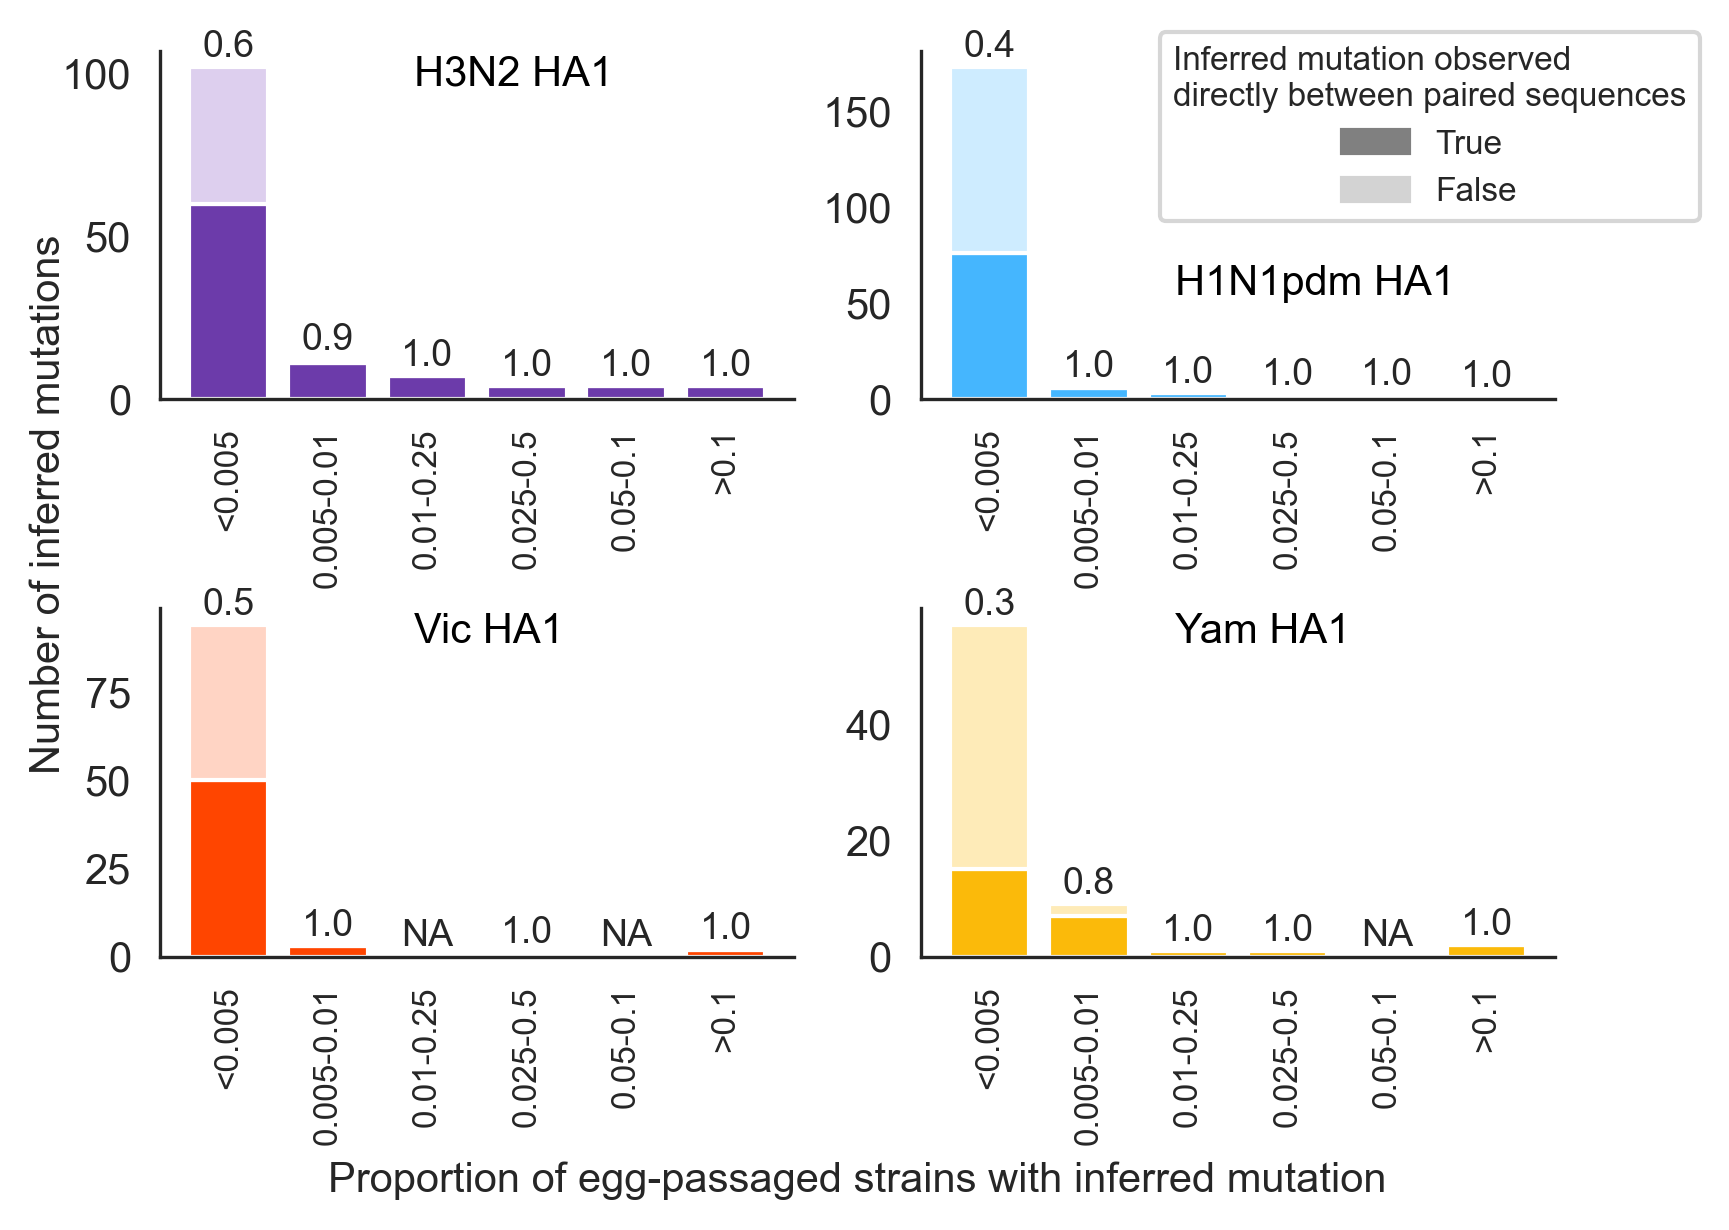

In [10]:
make_review_fig('site', filename='Supplement-mutValidation/mut_validation.png')

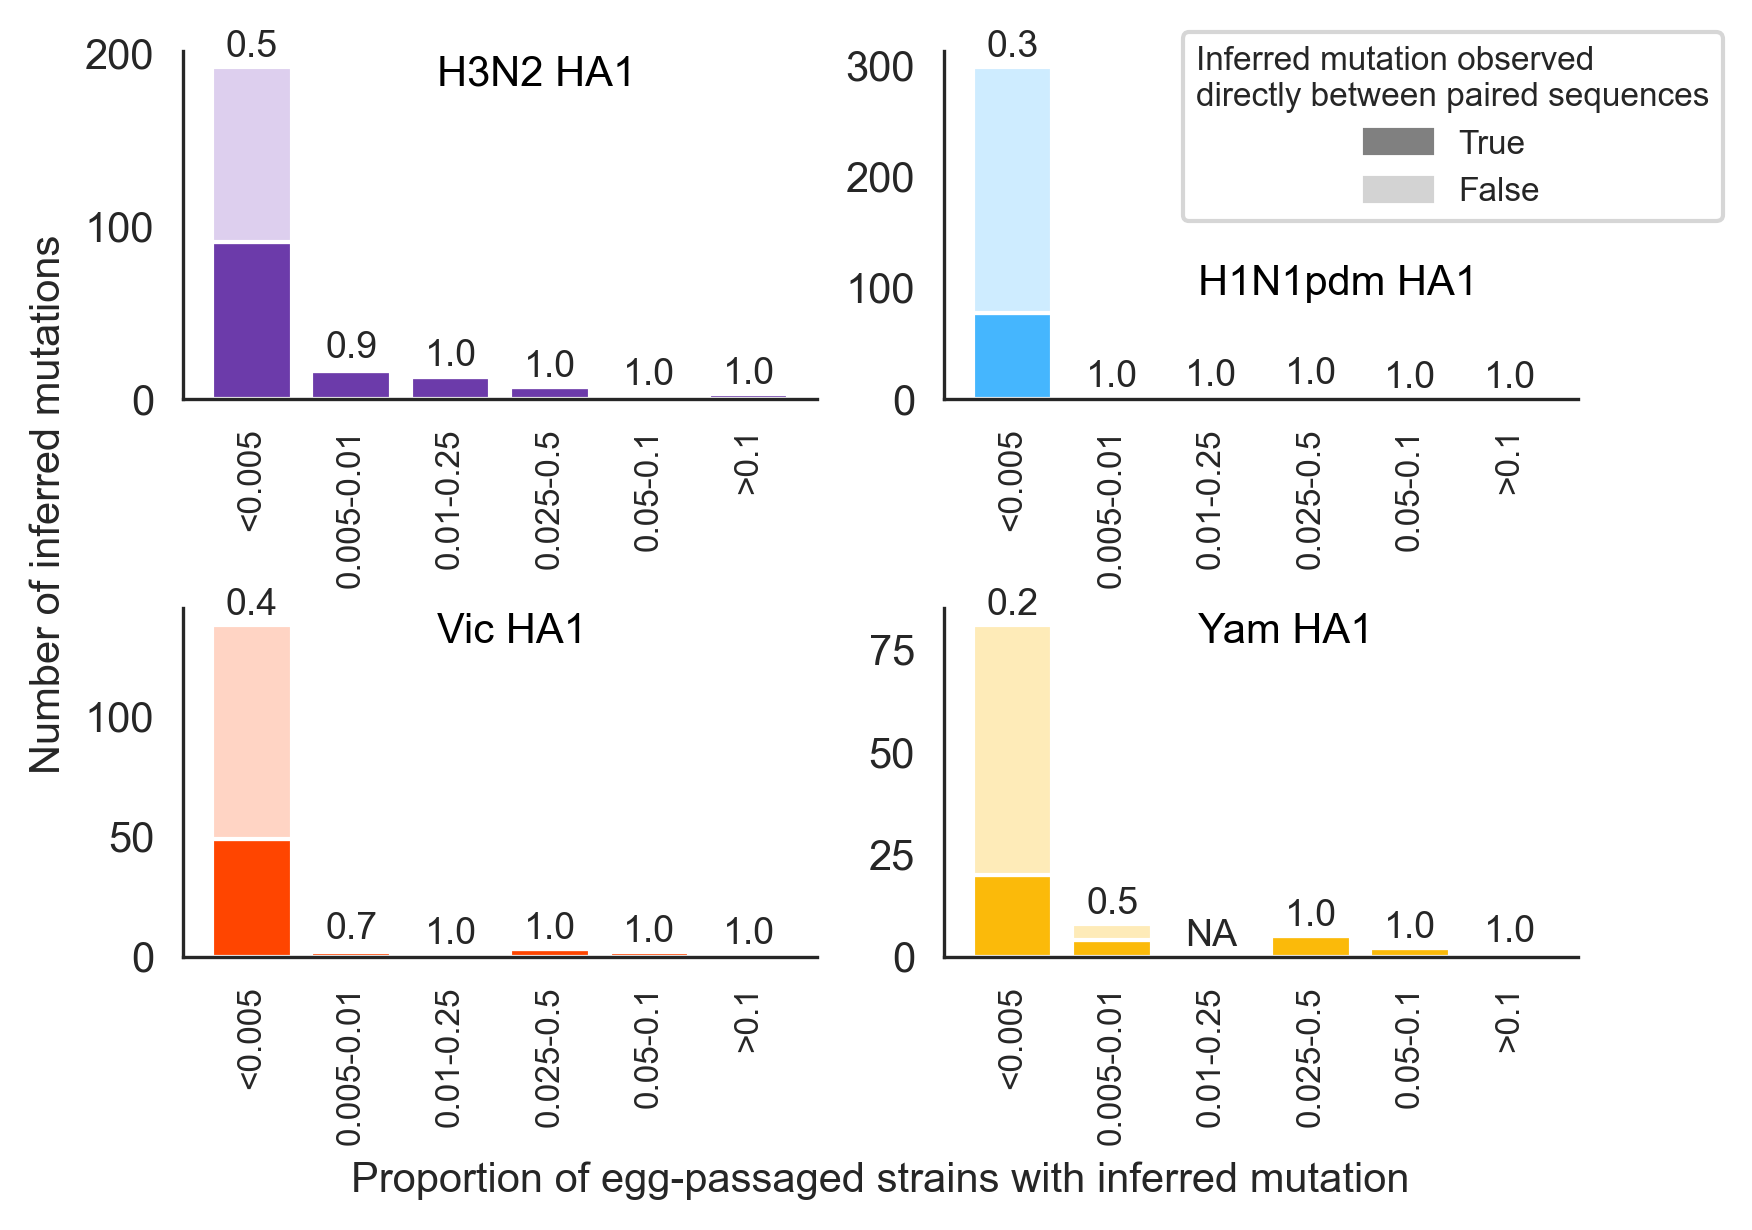

In [246]:
make_review_fig('aa')

In [71]:
# def compare_alignment_muts_to_tree_muts(virus, segment='ha', gene='HA1'):
#     """
#     For each egg strain, compare the the mutations that were inferred from the tree to those 
#     that are found directly by comparing the egg seq to the paired seq
#     """
    
#     alignment_egg_mutations = get_pair_muts_from_alignment(virus, segment, gene)
    
#     tree_egg_mutations = get_muts(virus, segment, gene)
    
#     count_agree = 0
#     count_dont_agree = 0
    
#     # say that alignment is "truth"
#     true_pos = 0
#     false_pos = 0
#     false_neg = 0
    
#     for egg_strain, a_muts in alignment_egg_mutations.items():
#         t_muts = tree_egg_mutations[egg_strain]
#         if a_muts != t_muts:
#             count_dont_agree+=1
            
#             # find number of "true muts" (from alignment) that are also found on tree
#             true_pos += sum(1 for x in a_muts if x in t_muts)
#             # if an a_mut is not seen in t_mut, that's a false_neg
#             false_neg += (len(a_muts) - sum(1 for x in a_muts if x in t_muts))
#             # if a t_mut is not seen in a_mut, its a false_pos
#             false_pos += (len(t_muts) - sum(1 for x in a_muts if x in t_muts))
#         else:
#             count_agree+=1
#             true_pos+=len(a_muts)
            
#     print(true_pos,false_pos, false_neg)

In [243]:
# compare_alignment_muts_to_tree_muts('h3n2', 'ha', 'HA1')